# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Maribao, Jake Agustin
- _Student No._: 2023-08777
- _Section_: TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

PART 1
![image.png](figure1.png) 
This script demonstrates catastrophic cancellation in √(x²+x) − x, which for large x subtracts two nearly-equal large numbers to recover a true value of only ~0.5. I rewrote it via conjugate multiplication into the factored form 1/(√(1+1/x)+1), chosen specifically because it never forms x² and so avoids the cancellation. The figure plots manual vs rewritten on a log-x axis and shades where they diverge, plus a bonus panel showing the manual form's relative error rising with x across float16/32/64/128, since coarser precision fails at smaller x.

PART 2
![image.png](figure2.png)
This script demonstrates catastrophic cancellation in (eˣ − 1)/x near x = 0, where eˣ ≈ 1 so the subtraction discards most of the significant digits and the manual form's relative error grows like eps/|x|. I resolved it by substituting the Maclaurin series (eˣ − 1)/x = 1 + x/2 + x²/6 + x³/24 + …, which computes the value directly with no subtraction, and plotted it against the manual form on a log-x axis with the cancellation region shaded. The bonus panel compares the manual form's relative error across float16/32/64/128, which is measured against a high-accuracy np.expm1 reference, where the onset moves to larger x as precision drops since the failure begins once x shrinks to around eps.

### Report discussion

Both formulas are algebraically identical, so the difference is purely numerical. The "bad" forms subtract two nearly-equal numbers. In Part 1, √(x²+x) − x for large x (both terms ≈ x, true answer only ≈ 0.5). In Part 2, eˣ − 1 for x ≈ 0 (both terms ≈ 1, true answer ≈ 1). When you subtract nearly-equal numbers, the leading digits cancel and only the noisy trailing digits survive, so the result loses most of its significant figures. That is the difference, the "bad" form computes a small quantity as the tiny leftover of two large ones which allows rounding error to dominate.

What makes "good" good is that it never performs that subtraction. Part 1 uses conjugate multiplication that resulted to 1/(√(1+1/x)+1). Part 2 uses the Maclaurin series 1 + x/2 + x²/6 + …. Both build the answer additively, so no digits cancel and full precision is retained.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
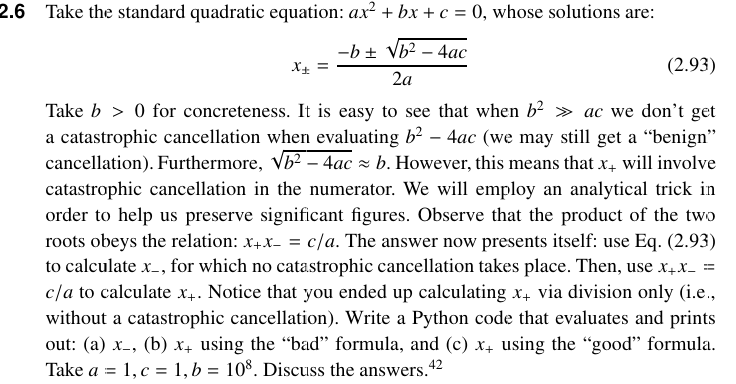

In [21]:
# (a)
import numpy as np

def quad_eq_sol_neg_root(a, b, c):
    discriminant = np.sqrt(b**2-4*a*c)
    x_neg = (-b-discriminant)/(2*a)
    return x_neg

print(quad_eq_sol_neg_root(1, 10**8, 1))

# This code prints out the negative root solution of a quadratic function.
# I defined the function using the typical quadratic equation solution for the negative root.

-100000000.0


In [23]:
# (b)
import numpy as np

def bad_quad_eq_sol_pos_root(a, b, c):
    discriminant = np.sqrt(b**2-4*a*c)
    x_pos = (-b+discriminant)/(2*a)
    return x_pos

print(bad_quad_eq_sol_pos_root(1, 10**8, 1))

# This code prints out the positive root solution of a quadratic function.
# I defined the function using the typical quadratic equation solution (the "bad" formula) for the positive root.

-7.450580596923828e-09


In [25]:
# (c)
import numpy as np

def good_quad_eq_sol_pos_root(a, b, c):
    discriminant = np.sqrt(b**2-4*a*c)
    x_neg = (-b-discriminant)/(2*a)
    x_pos = c/(x_neg*a)
    return x_pos

print(good_quad_eq_sol_pos_root(1, 10**8, 1))

# This code prints out the positive root solution of a quadratic function.
# I defined the function using the typical quadratic equation for the negative root.
# I then used the value of the negative root to get the positive root by using the product of roots formula.

-1e-08


#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation?
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [ ]:
# The catastrophic cancellation occurs when x>>1.

In [ ]:
# We multiply and divide with the conjugate of the expression to eliminate the subtraction operation.

# g(x) = sqrt(x^2+x)-x * [sqrt(x^2+x)+x]/[sqrt(x^2+x)+x] ==> g(x) = 1/[sqrt(1+(1/x))+1]


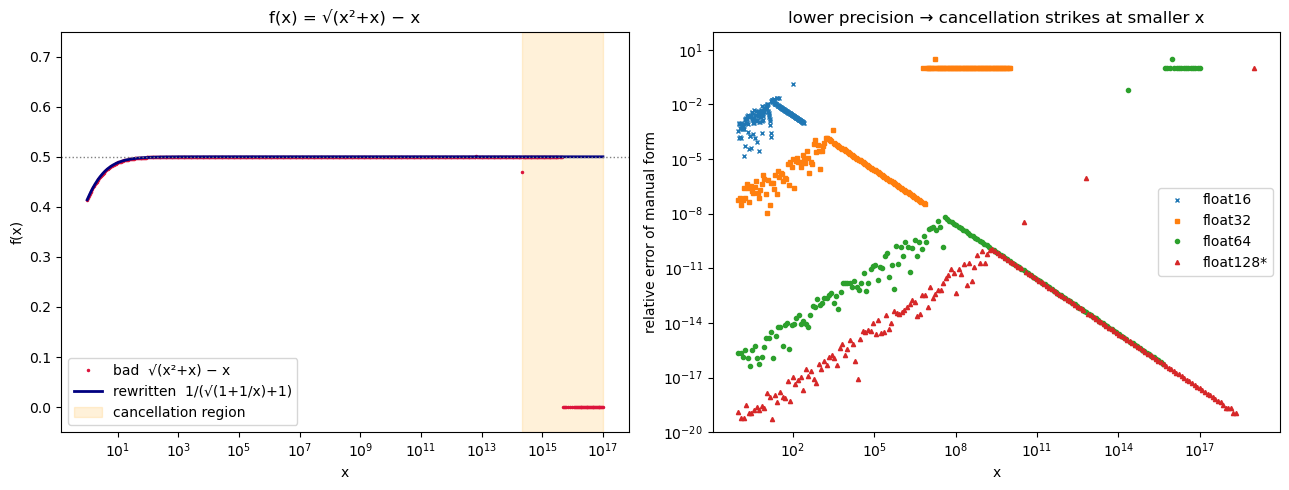

In [67]:
import numpy as np 
import matplotlib.pyplot as plt

f_bad = lambda x: np.sqrt(x**2 + x) - x
f_good   = lambda x: 1/(np.sqrt(1 + 1/x) + 1)
truth    = lambda x: f_good(np.asarray(x, np.longdouble))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.logspace(0, 17, 600)
ax1.plot(x, f_bad(x), '.', ms=3, c='crimson', label='bad  √(x²+x) − x')
ax1.plot(x, f_good(x),   '-', lw=2, c='navy',    label='rewritten  1/(√(1+1/x)+1)')
ax1.axhline(0.5, ls=':', c='gray', lw=1)
bad = x[np.abs(f_bad(x) - f_good(x)) / f_good(x) > 0.01]
ax1.axvspan(bad.min(), x.max(), color='orange', alpha=0.15, label='cancellation region')
ax1.set(xscale='log', ylim=(-0.05, 0.75), xlabel='x', ylabel='f(x)',
        title='f(x) = √(x²+x) − x'); ax1.legend(loc='lower left')

for dt, name, mk, hi in [(np.float16,'float16','x',3e2), (np.float32,'float32','s',1e10),
                         (np.float64,'float64','o',1e17), (np.longdouble,'float128*','^',1e19)]:
    xp = np.logspace(0, np.log10(hi), 200).astype(dt)
    with np.errstate(over='ignore', invalid='ignore'):
        err = np.abs((np.sqrt(xp**2+xp)-xp).astype(np.longdouble) - truth(xp)) / truth(xp)
    ax2.plot(xp.astype(float), err.astype(float), mk, ms=3, label=name)
ax2.set(xscale='log', yscale='log', ylim=(1e-20,1e2), xlabel='x',
        ylabel='relative error of manual form',
        title='lower precision → cancellation strikes at smaller x'); ax2.legend(loc='center right')
plt.tight_layout()
plt.savefig('figure1')
plt.show()

# This script demonstrates catastrophic cancellation in √(x²+x) − x, which for large x subtracts two nearly-equal large numbers to recover a true value of only ~0.5.
# I rewrote it via conjugate multiplication into the factored form 1/(√(1+1/x)+1). 
# The figure plots manual vs rewritten on a log-x axis and shades where they diverge, plus a bonus panel showing the manual form's relative error rising with x across float 16/32/64/128, since coarser precision fails at smaller x.

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [ ]:
# The catastrophic cancellation occurs when x≈0.

In [ ]:
# Substitute the Maclaurin series representation of e^x into the expression.

# h(x) = [(1 + x + (x^2/2!) + (x^3/3!) + ...) - 1]/x

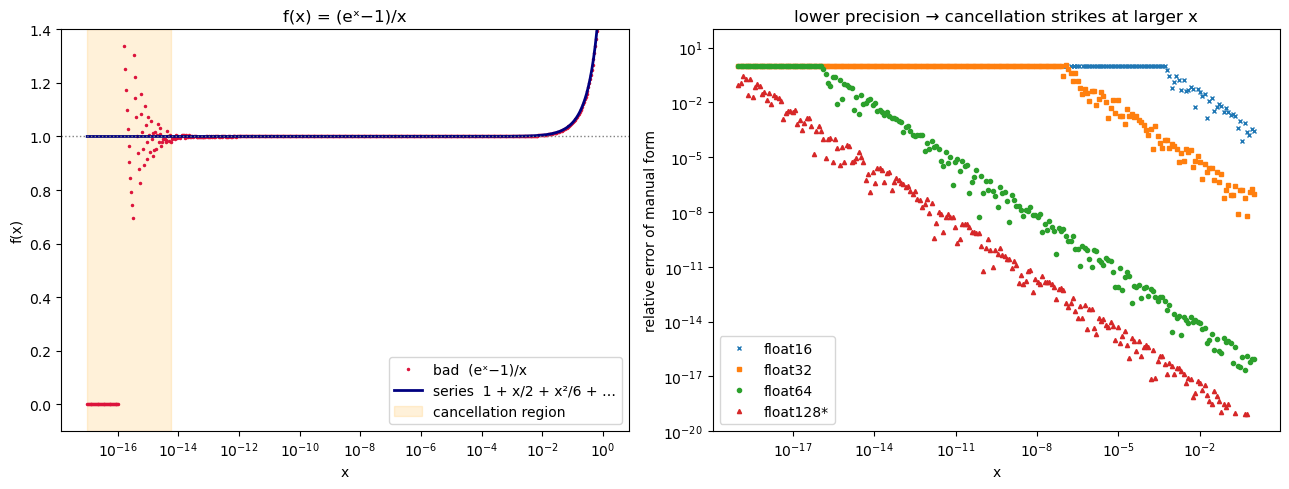

In [66]:
import numpy as np
import matplotlib.pyplot as plt

f_bad = lambda x: (np.exp(x) - 1) / x
f_good = lambda x: 1 + x/2 + x**2/6 + x**3/24 + x**4/120
truth    = lambda x: np.expm1(np.asarray(x, np.longdouble)) / np.asarray(x, np.longdouble)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.logspace(-17, 0, 600)
ax1.plot(x, f_bad(x), '.', ms=3, c='crimson', label='bad  (eˣ−1)/x')
ax1.plot(x, f_good(x), '-', lw=2, c='navy', label='series  1 + x/2 + x²/6 + …')
ax1.axhline(1.0, ls=':', c='gray', lw=1)
bad = x[np.abs(f_bad(x) - f_good(x)) / f_good(x) > 0.01]
ax1.axvspan(x.min(), bad.max(), color='orange', alpha=0.15, label='cancellation region')
ax1.set(xscale='log', ylim=(-0.1, 1.4), xlabel='x', ylabel='f(x)',
        title='f(x) = (eˣ−1)/x'); ax1.legend(loc='lower right')

for dt, name, mk in [(np.float16,'float16','x'), (np.float32,'float32','s'),
                     (np.float64,'float64','o'), (np.longdouble,'float128*','^')]:
    xp = np.logspace(-19, 0, 220).astype(dt)
    with np.errstate(invalid='ignore', divide='ignore'):
        err = np.abs(((np.exp(xp)-dt(1))/xp).astype(np.longdouble) - truth(xp)) / truth(xp)
    ax2.plot(xp.astype(float), err.astype(float), mk, ms=3, label=name)
ax2.set(xscale='log', yscale='log', ylim=(1e-20,1e2), xlabel='x',
        ylabel='relative error of manual form',
        title='lower precision → cancellation strikes at larger x'); ax2.legend(loc='lower left')
plt.tight_layout()
plt.savefig('figure2')
plt.show()

# This script demonstrates catastrophic cancellation in (eˣ − 1)/x near x = 0, where eˣ ≈ 1 so the subtraction discards most of the significant digits. 
# I resolved it by substituting the Maclaurin series (eˣ − 1)/x = 1 + x/2 + x²/6 + x³/24 + …, which computes the value directly with no subtraction, and plotted it against the manual form on a log-x axis with the cancellation region shaded. 
# The bonus panel compares the manual form's relative error across float16/32/64/128 which is measured against a high-accuracy np.expm1 reference.

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
